## 사전셋팅

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


구글 드라이브에는 다음과 같은 형태로 업로드한다.

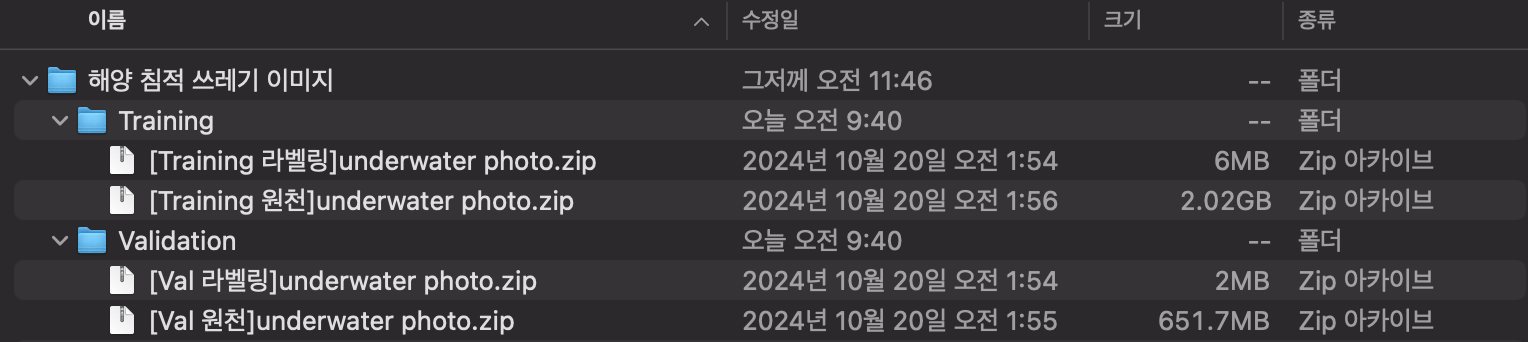

## 미션 1-1
.zip 파일의 압축을 풀고 Training 폴더와
Test 폴더를 만든다. Training과 Test 데이터의 이미지 수
는 각각 얼마인가?

압축폴더 해제

In [ ]:
!unzip -qq '/content/drive/MyDrive/seungbo/datasets/Training/[Training 라벨링]underwater photo.zip' -d '/content/drive/MyDrive/seungbo/datasets/Training/Training_labels'

In [ ]:
!unzip -qq '/content/drive/MyDrive/seungbo/datasets/Training/[Training 원천]underwater photo.zip' -d '/content/drive/MyDrive/seungbo/datasets/Training/Training_photo'

In [ ]:
!unzip -qq '/content/drive/MyDrive/seungbo/datasets/Validation/[Val 라벨링]underwater photo.zip' -d '/content/drive/MyDrive/seungbo/datasets/Validation/Val_labels'

In [ ]:
!unzip -qq '/content/drive/MyDrive/seungbo/datasets/Validation/[Val 원천]underwater photo.zip' -d '/content/drive/MyDrive/seungbo/datasets/Validation/val_photo'

Training과 Test 데이터의 이미지 수 확인

In [ ]:
import os

folder_path = "/content/drive/MyDrive/seungbo/datasets/Training/Training_photo"
file_list = os.listdir(folder_path)
file_count = len(file_list)
print("Training의 총 이미지 수는", file_count)

9023


In [ ]:
import os

folder_path = "/content/drive/MyDrive/seungbo/datasets/Validation/val_photo"
file_list = os.listdir(folder_path)
file_count = len(file_list)
print("Test의 총 이미지 수는", file_count)

3008


## 미션 1-2

**.xml 형태의 라벨링 데이터를 읽는 코드를 작성하고,
내용을 분석하여 다음의 질문에 답하라.
- 총 몇 종류의 object가 있는가?
- 각 object 종류별로 training 영상과 test 영상이 각각 몇 개
씩 있는가?
※ 단, object 종류 중 “other objects”는 삭제한다.

### 참고 링크
- https://docs.python.org/ko/3/library/xml.etree.elementtree.html#xml.etree.ElementTree.Element.iter
- https://king-rabbit.github.io/python/xml-parsing/
- https://wikidocs.net/21137
- https://todaycodeplus.tistory.com/54

In [ ]:
# xml 분석하기
for i in root.findall('object'):
    class_name = i.find('name').text
    print('클래스명:',class_name) # 클래스명 출력하기
    xmin = i.find('bndbox').find('xmin').text
    ymin = i.find('bndbox').find('ymin').text
    xmax = i.find('bndbox').find('xmax').text
    ymax = i.find('bndbox').find('ymax').text
    # 바운딩 박스 좌표 출력
    print('xmin', xmin)
    print('ymin', ymin)
    print('xmax', xmax)
    print('ymax', ymax)
    print()

클래스명: wood
xmin 119.74986064659973
ymin 386.1688701923077
xmax 1759.453125
ymax 709.1201574693423

클래스명: tire
xmin 1484.8325892857142
ymin 0.0
xmax 1765.1450892857142
ymax 164.42164606227112

클래스명: fish net
xmin 1215.8452460814387
ymin 258.451961676889
xmax 1457.3712238704122
ymax 388.2932747520515



In [ ]:
# xml을 보기 좋게 바꿔주는 함수
def indent(elem, level=0):
    i = "\n" + level * "  "
    if len(elem):
        if not elem.text or not elem.text.strip():
            elem.text = i + "  "
        if not elem.tail or not elem.tail.strip():
            elem.tail = i
        for child in elem:
            indent(child, level + 1)
        if not elem.tail or not elem.tail.strip():
            elem.tail = i
    else:
        if level and (not elem.tail or not elem.tail.strip()):
            elem.tail = i

xml 파싱하기

In [ ]:
import xml.etree.ElementTree as ET

tree = ET.parse('/content/drive/MyDrive/seungbo/datasets/Training/Training_labels/wood_tire_fish net_046_01996.xml')
root = tree.getroot()

print(root)
indent(root)
ET.dump(root)

<Element 'annotation' at 0x7fb70776e250>
<annotation>
  <folder>[underwater photo]</folder>
  <filename>wood_tire_fish net_046_01996.jpg</filename>
  <path>../../[image]/[underwater photo]/wood_tire_fish net_046_01996.jpg</path>
  <size>
    <width>1920</width>
    <height>1080</height>
    <depth>3</depth>
    </size>
  <commoninfo>
    <datasetname>underwater photo dataset</datasetname>
    <createdate>2021-02-02 06:51:28.0</createdate>
    </commoninfo>
  <metainfo>
    <device>Cannon EOS 100D</device>
    <location>
      <name>Daejin Port</name>
      <latitude>
        <DMS />
        <DMM />
        <DD>38.500066</DD>
        </latitude>
      <longitude>
        <DMS />
        <DMM />
        <DD>128.428822</DD>
        </longitude>
      </location>
    <depth-of-water />
    <temperature />
    <NTU />
    </metainfo>
  <object>
    <name>wood</name>
    <bndbox>
      <xmin>119.74986064659973</xmin>
      <ymin>386.1688701923077</ymin>
      <xmax>1759.453125</xmax>
      <

In [ ]:
import os

file_dir = '/content/drive/MyDrive/seungbo/datasets/Validation/Val_labels/'

file_list = os.listdir(file_dir)

class_names = {}

for file in file_list :
  if file.endswith('.xml'):
    tree = ET.parse(file_dir + '/' + str(file))
    root = tree.getroot()

    for i in root.findall('object'):
      name = i.find('name').text
      if name in class_names:
        class_names[name] += 1
      else:
        class_names[name] = 1
print(f"총 {len(class_names.keys())}개의 종류의 클래스가 존재")

for a, b in class_names.items():
  print(a, ":", b)

KeyboardInterrupt: 

other objects, other objets 삭제할 필요 보임!

In [ ]:
import os

file_dir = '/content/drive/MyDrive/seungbo/datasets/Training/Training_labels'

file_list = os.listdir(file_dir)

class_names = {}

for file in file_list :
  if file.endswith('.xml'):
    tree = ET.parse(file_dir + '/' + str(file))
    root = tree.getroot()
    for i in root.findall('object'):
      name = i.find('name').text
      if name in class_names:
        class_names[name] += 1
      else:
        class_names[name] = 1

for a, b in class_names.items():
  print(a, ":", b)

KeyboardInterrupt: 

othe objects 삭제할 필요 보임

#### xml 삭제 테스트

In [ ]:
import xml.etree.ElementTree as ET

tree = ET.parse('/content/drive/MyDrive/seungbo/datasets/Validation/Val_labels/eel fish trap_other objets_004_00448.xml')

tree = ET.parse('./asdf.xml')


root = tree.getroot()

indent(root)
print(root)
ET.dump(root)

<Element 'annotation' at 0x7fb707718b30>
<annotation>
  <folder>[underwater photo]</folder>
  <filename>eel fish trap_other objets_004_00448.jpg</filename>
  <path>../../[image]/[underwater photo]/eel fish trap_other objets_004_00448.jpg</path>
  <size>
    <width>1280</width>
    <height>720</height>
    <depth>3</depth>
    </size>
  <commoninfo>
    <datasetname>underwater photo dataset</datasetname>
    <createdate>2021-04-20 13:40:01.0</createdate>
    </commoninfo>
  <metainfo>
    <device>Cannon EOS 100D</device>
    <location>
      <name>Guryongpo</name>
      <latitude>
        <DMS />
        <DMM />
        <DD>35.987252</DD>
        </latitude>
      <longitude>
        <DMS />
        <DMM />
        <DD>129.556157</DD>
        </longitude>
      </location>
    <depth-of-water />
    <temperature />
    <NTU />
    </metainfo>
  <object>
    <name>eel fish trap</name>
    <bndbox>
      <xmin>70.78125</xmin>
      <ymin>233.0712890625</ymin>
      <xmax>1230.625</xmax>
 

In [ ]:
for i in root.findall('object'):
      name = i.find('name').text
      if name == 'other objets':
        root.remove(i)
ET.dump(root)

<annotation>
  <folder>[underwater photo]</folder>
  <filename>eel fish trap_other objets_004_00448.jpg</filename>
  <path>../../[image]/[underwater photo]/eel fish trap_other objets_004_00448.jpg</path>
  <size>
    <width>1280</width>
    <height>720</height>
    <depth>3</depth>
    </size>
  <commoninfo>
    <datasetname>underwater photo dataset</datasetname>
    <createdate>2021-04-20 13:40:01.0</createdate>
    </commoninfo>
  <metainfo>
    <device>Cannon EOS 100D</device>
    <location>
      <name>Guryongpo</name>
      <latitude>
        <DMS />
        <DMM />
        <DD>35.987252</DD>
        </latitude>
      <longitude>
        <DMS />
        <DMM />
        <DD>129.556157</DD>
        </longitude>
      </location>
    <depth-of-water />
    <temperature />
    <NTU />
    </metainfo>
  <object>
    <name>eel fish trap</name>
    <bndbox>
      <xmin>70.78125</xmin>
      <ymin>233.0712890625</ymin>
      <xmax>1230.625</xmax>
      <ymax>527.1337890625</ymax>
      <w

In [ ]:
tree.write('./asdf.xml', encoding='utf-8', xml_declaration=True)

## 미션 1-3

 **.xml 파일에서 제공되는 바운딩박스 메타데이터
(<bndbox>)를 이용하여 대응되는 영상에 바운딩박스를
plot한다. 각 object 종류별로 한 개의 샘플 영상을 시각화
하여야 하며, 바운딩박스의 테두리 색상은 object 종류에
따라 다른 색상을 사용한다

### 참고
- https://supermemi.tistory.com/entry/PyTorch-torchvision-drawboundingboxes-%EC%82%AC%EC%9A%A9%ED%95%98%EA%B8%B0

In [ ]:
import os

file_dir = '/content/drive/MyDrive/seungbo/datasets/Validation/Val_labels/'

file_list = os.listdir(file_dir)

a = 0

dir_list = []
name_list = []

for file in file_list :
  if file.endswith('.xml'):
    tree = ET.parse(file_dir + '/' + str(file))
    root = tree.getroot()
    for i in root.findall('object'):
      name = i.find('name').text
      if file in dir_list:
        continue
      if name in name_list:
        continue
      if a >= 10:
        break
      print(name,':', file)
      dir_list.append(file)
      name_list.append(name)
      a+=1

spring fish trap : spring fish trap_rope_046_00315.xml
tire : tire_046_02498.xml
fish net : fish net_046_02819.xml
rope : tire_rope_046_01638.xml
circular fish trap : circular fish trap_bundle of ropes_047_01673.xml
bundle of ropes : bundle of ropes_046_01396.xml
wood : wood_046_01584.xml
rectangular fish trap : rectangular fish trap_bundle of ropes_047_00001.xml
eel fish trap : eel fish trap_bundle of ropes_047_00774.xml
bundle of rope : circular fish trap_bundle of rope_042_09579.xml


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import torchvision.transforms.functional as F

plt.rcParams["savefig.bbox"] = 'tight'

def show(imgs):
    if not isinstance(imgs, list): # 하나의 이미지일때
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False) # 총 사진의 개수만큼 plot
    for i, img in enumerate(imgs):
        img = img.detach() # 학습 그래프에서 제외
        img = F.to_pil_image(img) # torch.tensor 에서 pil 이미지로 변환
        axs[0, i].imshow(np.asarray(img)) # numpy 배열로 변경후, 가로로 이미지를 나열
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

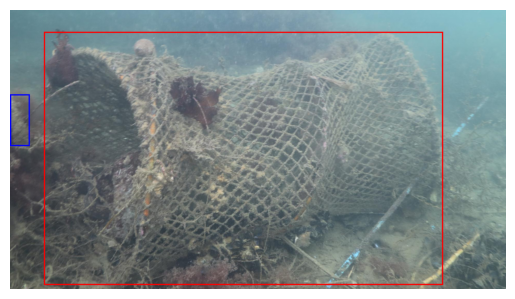

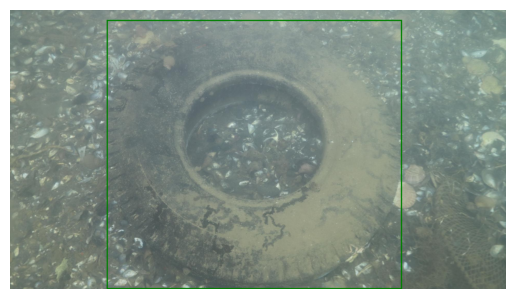

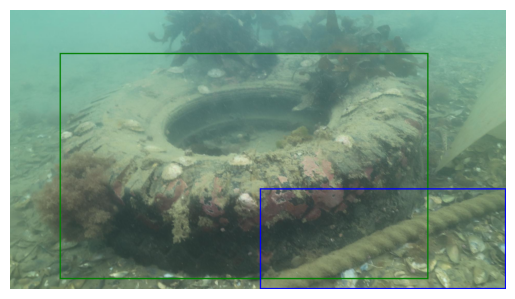

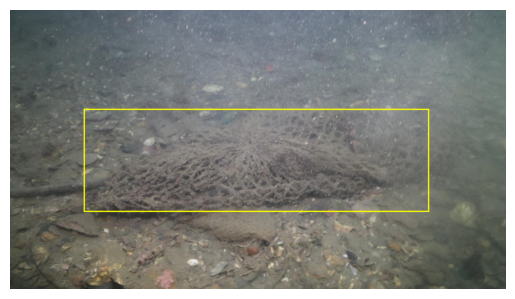

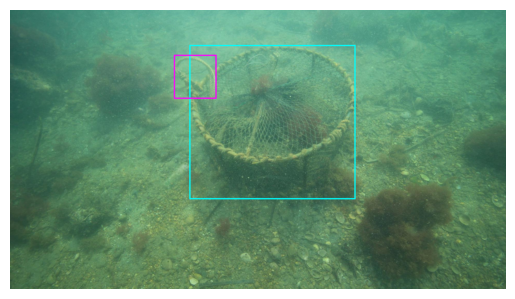

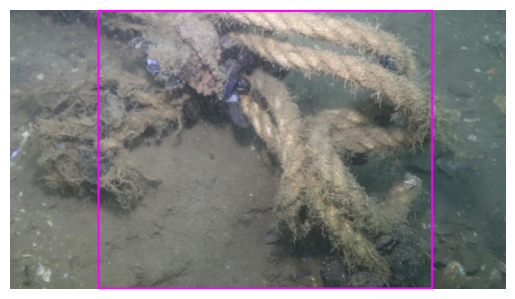

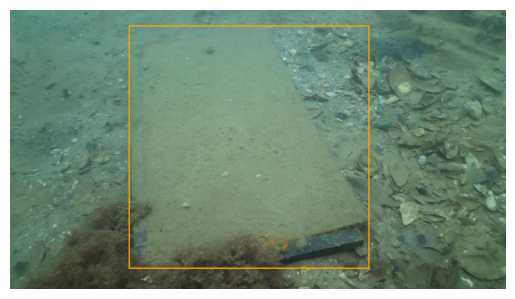

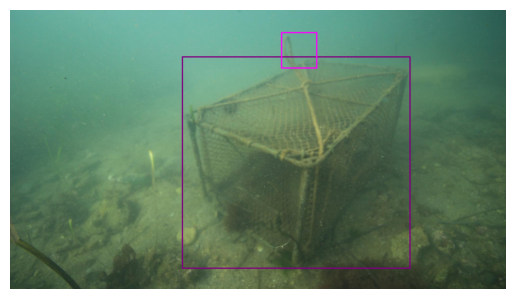

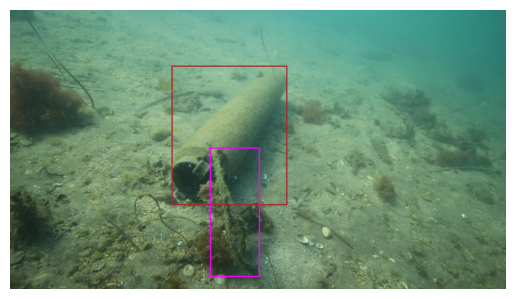

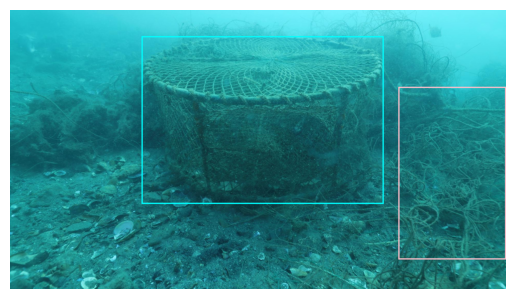

In [ ]:
labeltoimage = ['spring fish trap_rope_046_00315', 'tire_046_02498', 'tire_rope_046_01638', 'fish net_046_02819',
                'circular fish trap_bundle of ropes_047_01673', 'bundle of ropes_046_01396', 'wood_046_01584',
                'rectangular fish trap_bundle of ropes_047_00001', 'eel fish trap_bundle of ropes_047_00774', 'circular fish trap_bundle of rope_042_09579']

# 클래스별 색상을 지정한 딕셔너리
class_to_color = {
    "spring fish trap": "red",
    "rope": "blue",
    "tire": "green",
    "fish net":"Yellow",
    "circular fish trap":"Cyan",
    "bundle of ropes":"Magenta",
    "wood":"Orange",
    "rectangular fish trap":"Purple",
    "eel fish trap":"Brown",
    "bundle of rope":"Pink"
}

for img_id in labeltoimage:
    # 이미지를 불러오기
    image = read_image(str(Path('/content/drive/MyDrive/seungbo/datasets/Validation/val_photo/') / f"{img_id}.jpg"))

    # XML 파일 파싱
    tree = ET.parse(f"/content/drive/MyDrive/seungbo/datasets/Validation/Val_labels/{img_id}.xml")
    root = tree.getroot()

    boxes = []        # 모든 바운딩 박스를 담을 리스트
    colors = []       # 각 바운딩 박스에 해당하는 색상을 담을 리스트

    # 바운딩 박스 정보 수집
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        xmin = float(obj.find('bndbox').find('xmin').text)
        ymin = float(obj.find('bndbox').find('ymin').text)
        xmax = float(obj.find('bndbox').find('xmax').text)
        ymax = float(obj.find('bndbox').find('ymax').text)

        # 바운딩 박스를 리스트에 추가
        boxes.append([xmin, ymin, xmax, ymax])

        # 해당 클래스의 색상 지정 (없는 클래스는 기본 색상 사용)
        color = class_to_color.get(class_name, "yellow")  # 기본 색상은 노란색
        colors.append(color)

    # 텐서로 변환
    boxes_tensor = torch.tensor(boxes, dtype=torch.float)

    # 모든 바운딩 박스를 한 번에 그리기
    result = draw_bounding_boxes(image, boxes_tensor, colors=colors, width=5)

    # 이미지 시각화
    plt.imshow(result.permute(1, 2, 0))  # 이미지를 (H, W, C) 형식으로 변환하여 matplotlib에 전달
    plt.axis('off')
    # plt.title(", ".join(class_to_color.keys()))  # 포함된 클래스명을 타이틀에 표시
    plt.show()


## 미션 2-1 -> 박주은, 류현정

Object detection(객체인식) 모델을 학습하기 위해 영상 데이터와 메타데이터를
Google colab으로 업로드하여야 한다. 이와 관련하여 다음의 질문에 답하라.
- 개별 파일로 존재하는 영상 데이터와 메타 데이터를 어떠한 방식으로 업로드 하였는가?
- 영상 데이터와 메타 데이터를 Colab 환경에서 어떠한 구조로 저장하였는가?
해당 구조를 선택한 이유는 무엇인가?


**류현정**

- 구조 선택 이유

**조직적인 파일 관리**: 데이터와 라벨 파일을 Training과 Test로 분리하고 각 안에서 images와 annotations 폴더로 세분화함으로써 혼동을 최소화할 수 있습니다.

**Colab 디스크 용량 최적화**: 불필요한 파일 중복을 줄여 Colab의 제한된 디스크 공간을 효율적으로 사용합니다.

**코드**

= 사전 준비에서 1-1까지 코드에 포함됨.추가적인 코드 작성은 필요하지 않아 보입니다.

## 미션 3-1 -> 이승보

해양침적쓰레기 검출을 위하여 사용 가능한 알고리즘/모델에는 어떠한 것들이 있는가? 최소 3가지 이상의 알고리즘/모델을 탐색하고 그 중 한 가지를 선택하라. 선택한 이유에 대해서 설명하라.
- Faster R-CNN
- SSD
- Yolo


## 미션 3-2 -> 김찬희

선택한 알고리즘/모델을 구현/실행하여 mAP@IoU 50% (50% 이상 중첩되었을
경우의 mean Average Precision)을 계산하라.

## 미션 3-3 -> 최현우

모델이 잘못 분류한 영상/객체에 대해서 분석하고, 해당 문제의 발생 이유를 설명
하라.